# GVH `.28.21 SIDE-N2` — Fold Continuation in \(\rho\) and Time

**Type :** diagnostic numérique minimal.  
**Ne modifie pas la chaîne canonique.**

Objectif :

\[
\boxed{
\text{continuation au fold en }\rho
\rightarrow
\text{continuation au fold en }t
}
\]

Le but est uniquement de vérifier numériquement le résultat analytique de `.28.20.7.1` :

\[
\boxed{
\text{le fold de }q(H^2)
\text{ est un fold de projection, pas une terminaison du fond homogène couplé.}
}
\]

Aucune donnée réelle. Aucune calibration SI.

In [1]:
from __future__ import annotations
import json, math, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CANON = {
    "sha256":"d8a256ab92abecab6a0871efdffc9f06c50726900bcb60a2abfce6a5d6a6b1f4",
    "size":29925,
}
SIDE1 = {
    "sha256":"b2f04296c31060e7990a776526e1571ec9124f0bbaa33cd073d05dc833c9a3a3",
    "size":108556,
}

assert CANON["sha256"] == "d8a256ab92abecab6a0871efdffc9f06c50726900bcb60a2abfce6a5d6a6b1f4"
assert SIDE1["sha256"] == "b2f04296c31060e7990a776526e1571ec9124f0bbaa33cd073d05dc833c9a3a3"

print("Python =",sys.version.split()[0])
print("NumPy =",np.__version__)
print("CANON_GATE = True")
print("SIDE_N1_GATE = True")

Python = 3.13.15
NumPy = 2.1.3
CANON_GATE = True
SIDE_N1_GATE = True


## 1 — Réduction dimensionless

On pose :

\[
s=\frac{q}{q_+},
\qquad
y=\frac{\alpha H^2}{a},
\qquad
R=\frac{8b^2\rho}{a^3},
\]

et :

\[
\chi=\frac{\alpha q_+^2}{2M^2}.
\]

Pour :

\[
U(q)=bq(q_+-q)^2,
\]

la contrainte radiale donne :

\[
\boxed{
y(s)=\frac{(1-s)(3s-1)}{6s}
}
\]

sur la branche \(q>0\).

La contrainte métrique donne :

\[
\boxed{
R(s)
=
\frac{3(1+\chi s^2)}{\chi}\,y(s)
-
s(1-s)^2.
}
\]

Le fold projeté est :

\[
\boxed{
s_c=\frac1{\sqrt3},
\qquad
y_c=\frac{2-\sqrt3}{3}.
}
\]

In [2]:
def y_of_s(s):
    s = np.asarray(s, dtype=float)
    return (1.0-s)*(3.0*s-1.0)/(6.0*s)

def R_of_s(s, chi):
    s = np.asarray(s, dtype=float)
    y = y_of_s(s)
    return 3.0*(1.0+chi*s*s)*y/chi - s*(1.0-s)**2

def dy_ds(s):
    s = np.asarray(s, dtype=float)
    # derivative of y=(1-s)(3s-1)/(6s)
    return (1.0 - 3.0*s*s)/(6.0*s*s)

def dR_ds(s, chi):
    # analytic derivative, evaluated from the explicit formula
    s = np.asarray(s, dtype=float)
    y = y_of_s(s)
    yp = dy_ds(s)
    return 3.0*((2.0*chi*s)*y + (1.0+chi*s*s)*yp)/chi - (
        (1.0-s)**2 - 2.0*s*(1.0-s)
    )

sc = 1.0/math.sqrt(3.0)
yc = (2.0-math.sqrt(3.0))/3.0

assert abs(y_of_s(sc)-yc) < 1e-14
assert abs(dy_ds(sc)) < 1e-14

print("s_c =",sc)
print("y_c =",yc)

s_c = 0.5773502691896258
y_c = 0.08931639747704094


## 2 — Paramètres prescrits du diagnostic

On choisit uniquement pour le témoin numérique :

\[
\boxed{\chi=1}
\]

et un fluide poussière :

\[
\boxed{w=0}.
\]

Ces valeurs sont **prescribed diagnostic witnesses**.

Elles ne sont ni dérivées ni calibrées.

Le choix \(\chi=1\) rend le fold accessible avec :

\[
R_c>0.
\]

In [3]:
chi = 1.0
w = 0.0

Rc = float(R_of_s(sc,chi))
Rpc = float(dR_ds(sc,chi))

print("chi =",chi)
print("w =",w)
print("R_c =",Rc)
print("dR/ds at fold =",Rpc)

assert Rc > 0
assert Rpc > 0

chi = 1.0
w = 0.0
R_c = 0.2541318976553293
dR/ds at fold = 0.6188021535170058


## 3 — Continuation numérique en densité \(R\)

Près du fold, puisque :

\[
\frac{dR}{ds}\Big|_c\neq0,
\]

on peut inverser localement :

\[
s=s(R).
\]

On construit une continuation monotone dans une fenêtre qui traverse \(s_c\).

La prédiction analytique est :

\[
\boxed{
\frac{ds}{dR}\Big|_c
=
\frac{1}{R'(s_c)}
}
\]

et :

\[
\boxed{
\frac{dy}{dR}\Big|_c=0.
}
\]

In [4]:
s_hi = sc + 0.055
s_lo = sc - 0.045

assert dR_ds(s_hi,chi) > 0
assert dR_ds(s_lo,chi) > 0

# Dense monotonic map s -> R across fold
s_dense = np.linspace(s_lo,s_hi,20001)
R_dense = R_of_s(s_dense,chi)

assert np.all(np.diff(R_dense) > 0)

R_targets = np.linspace(R_of_s(s_hi,chi), R_of_s(s_lo,chi), 241)

# invert monotonic relation by interpolation
s_from_R = np.interp(
    R_targets[::-1],
    R_dense,
    s_dense
)[::-1]
y_from_R = y_of_s(s_from_R)

idx_fold = int(np.argmin(np.abs(s_from_R-sc)))

dsdR_numeric = np.gradient(s_from_R,R_targets)
dydR_numeric = np.gradient(y_from_R,R_targets)

print("rho-continuation points =",len(R_targets))
print("nearest s to fold =",s_from_R[idx_fold])
print("numeric ds/dR near fold =",dsdR_numeric[idx_fold])
print("analytic ds/dR at fold =",1.0/Rpc)
print("numeric dy/dR near fold =",dydR_numeric[idx_fold])

assert np.isfinite(dsdR_numeric[idx_fold])

rho-continuation points = 241
nearest s to fold = 0.5772464844509482
numeric ds/dR near fold = 1.6144501874384787
analytic ds/dR at fold = 1.6160254037844393
numeric dy/dR near fold = 0.00028856513233677106


## 4 — Visualisation de la continuation en \(\rho\)

La variable \(s\) doit traverser continûment :

\[
s>s_c
\rightarrow
s=s_c
\rightarrow
s<s_c.
\]

En revanche \(y= \alpha H^2/a\) atteint un extremum au fold.

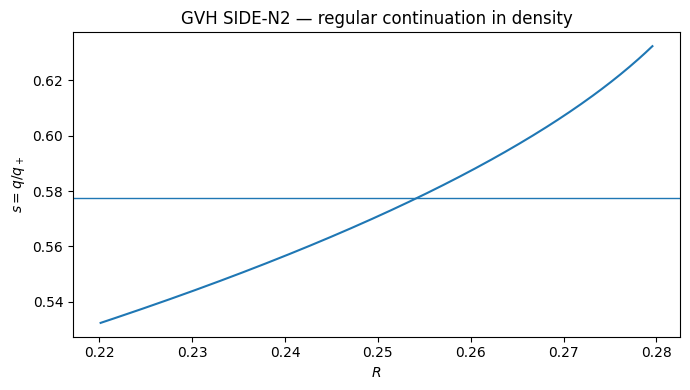

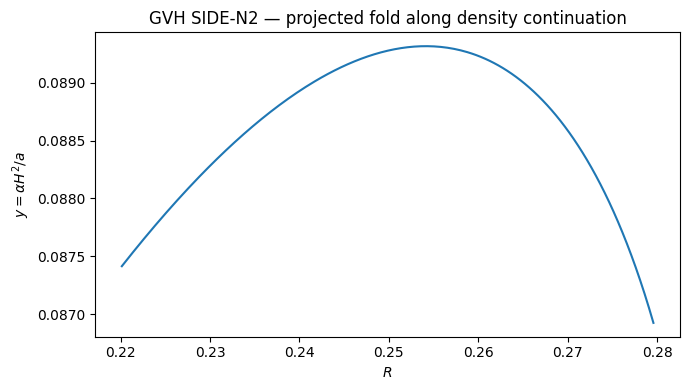

In [5]:
plt.figure(figsize=(7,4))
plt.plot(R_targets,s_from_R)
plt.axhline(sc,linewidth=1)
plt.xlabel(r"$R$")
plt.ylabel(r"$s=q/q_+$")
plt.title("GVH SIDE-N2 — regular continuation in density")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(R_targets,y_from_R)
plt.xlabel(r"$R$")
plt.ylabel(r"$y=\alpha H^2/a$")
plt.title("GVH SIDE-N2 — projected fold along density continuation")
plt.tight_layout()
plt.show()

## 5 — Passage au temps dimensionless

On définit :

\[
\tau=t\sqrt{\frac{a}{\alpha}}.
\]

Pour un fluide parfait :

\[
\dot\rho=-3H(1+w)\rho.
\]

En variables dimensionless :

\[
\boxed{
\frac{dR}{d\tau}
=
-3(1+w)\sqrt{y}\,R.
}
\]

Comme :

\[
R=R(s),
\]

on obtient :

\[
\boxed{
\frac{ds}{d\tau}
=
-\frac{3(1+w)\sqrt{y(s)}\,R(s)}
{R'(s)}.
}
\]

Cette équation reste finie au fold si :

\[
R'(s_c)\neq0.
\]

In [6]:
def ds_dtau(s, chi=1.0, w=0.0):
    y = float(y_of_s(s))
    R = float(R_of_s(s,chi))
    Rp = float(dR_ds(s,chi))
    return -3.0*(1.0+w)*math.sqrt(y)*R/Rp

v_c = ds_dtau(sc,chi,w)
print("ds/dtau at fold =",v_c)
assert math.isfinite(v_c)
assert v_c < 0

ds/dtau at fold = -0.3682088448436994


## 6 — Continuation temporelle paramétrique

Pour éviter d'introduire un solveur externe inutile, on utilise directement :

\[
\frac{d\tau}{ds}
=
-\frac{R'(s)}
{3(1+w)\sqrt{y(s)}R(s)}.
\]

On intègre numériquement cette quantité sur une grille décroissante en \(s\).

C'est un diagnostic minimal de la continuation régulière en temps.

In [7]:
s_track = np.linspace(s_hi,s_lo,1201)
y_track = y_of_s(s_track)
R_track = R_of_s(s_track,chi)
Rp_track = dR_ds(s_track,chi)

dtau_ds = -Rp_track/(3.0*(1.0+w)*np.sqrt(y_track)*R_track)

tau = np.zeros_like(s_track)
for i in range(1,len(s_track)):
    ds = s_track[i]-s_track[i-1]
    tau[i] = tau[i-1] + 0.5*(dtau_ds[i]+dtau_ds[i-1])*ds

assert np.all(np.diff(tau) > 0)

fold_i = int(np.argmin(np.abs(s_track-sc)))
tau_c = float(tau[fold_i])

print("time-track points =",len(s_track))
print("tau_c approx =",tau_c)
print("s(tau_c) approx =",s_track[fold_i])
print("y(tau_c) approx =",y_track[fold_i])

time-track points = 1201
tau_c approx = 0.10682762167825935
s(tau_c) approx = 0.5773502691896258
y(tau_c) approx = 0.08931639747704091


## 7 — Le fold devient un maximum temporel de \(H^2\)

La prédiction analytique est :

\[
\frac{dy}{d\tau}\Big|_c=0,
\]

avec :

\[
\frac{d^2y}{d\tau^2}\Big|_c<0
\]

si :

\[
\frac{ds}{d\tau}\Big|_c\neq0.
\]

Numériquement, on vérifie que le maximum de \(y(\tau)\) coïncide avec \(s\simeq s_c\).

In [8]:
imax = int(np.argmax(y_track))
s_at_ymax = float(s_track[imax])
tau_at_ymax = float(tau[imax])
ymax = float(y_track[imax])

dy_dtau_num = np.gradient(y_track,tau)
d2y_dtau2_num = np.gradient(dy_dtau_num,tau)

print("s at max(y) =",s_at_ymax)
print("s_c =",sc)
print("y max =",ymax)
print("y_c =",yc)
print("dy/dtau near max =",dy_dtau_num[imax])
print("d2y/dtau2 near max =",d2y_dtau2_num[imax])

assert abs(s_at_ymax-sc) < 2e-4
assert d2y_dtau2_num[imax] < 0

s at max(y) = 0.5773502691896258
s_c = 0.5773502691896258
y max = 0.08931639747704091
y_c = 0.08931639747704094
dy/dtau near max = 2.2514200281875674e-08
d2y/dtau2 near max = -0.23482806336501538


## 8 — Courbes temporelles

Le résultat recherché est une trajectoire régulière :

\[
s(\tau):
\quad
s>s_c
\rightarrow
s_c
\rightarrow
s<s_c,
\]

tandis que :

\[
y(\tau)
\]

atteint un maximum puis redescend.

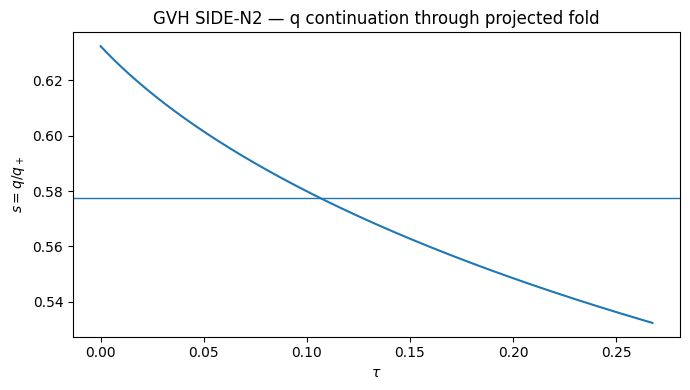

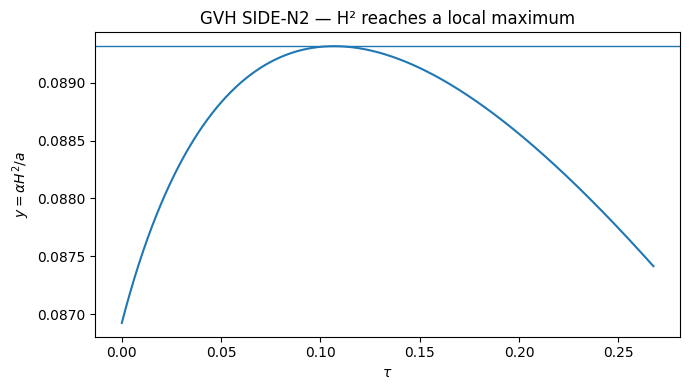

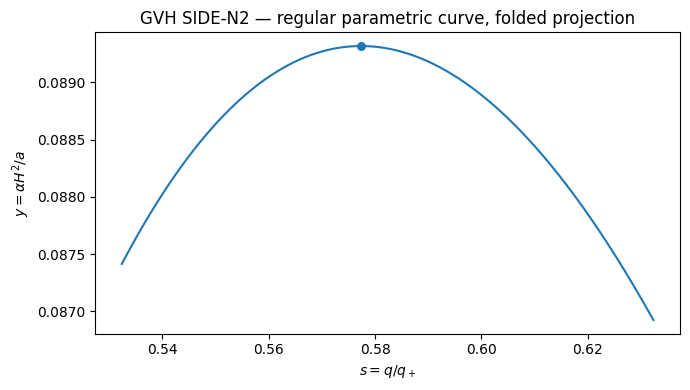

In [9]:
plt.figure(figsize=(7,4))
plt.plot(tau,s_track)
plt.axhline(sc,linewidth=1)
plt.xlabel(r"$\tau$")
plt.ylabel(r"$s=q/q_+$")
plt.title("GVH SIDE-N2 — q continuation through projected fold")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(tau,y_track)
plt.axhline(yc,linewidth=1)
plt.xlabel(r"$\tau$")
plt.ylabel(r"$y=\alpha H^2/a$")
plt.title("GVH SIDE-N2 — H² reaches a local maximum")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(s_track,y_track)
plt.scatter([sc],[yc],s=30)
plt.xlabel(r"$s=q/q_+$")
plt.ylabel(r"$y=\alpha H^2/a$")
plt.title("GVH SIDE-N2 — regular parametric curve, folded projection")
plt.tight_layout()
plt.show()

## 9 — Résidus numériques

On vérifie les deux relations algébriques dimensionless :

\[
E_{\rm dimless}
=
(1-s)(1-3s)+6sy=0,
\]

\[
C_{\rm dimless}
=
\frac{3(1+\chi s^2)}{\chi}y
-
s(1-s)^2
-
R=0.
\]

Leur résidu doit rester proche de la précision machine tout au long de la trajectoire.

In [10]:
E_res = (1.0-s_track)*(1.0-3.0*s_track) + 6.0*s_track*y_track
C_res = (
    3.0*(1.0+chi*s_track*s_track)*y_track/chi
    - s_track*(1.0-s_track)**2
    - R_track
)

max_E = float(np.max(np.abs(E_res)))
max_C = float(np.max(np.abs(C_res)))

print("max |E_dimless| =",max_E)
print("max |C_dimless| =",max_C)

assert max_E < 1e-12
assert max_C < 1e-12

max |E_dimless| = 0.0
max |C_dimless| = 0.0


## 10 — Verdict SIDE-N2

Ce diagnostic numérique montre, pour un témoin dimensionless prescrit :

\[
\boxed{
s(R)\text{ traverse régulièrement }s_c
}
\]

et :

\[
\boxed{
s(\tau)\text{ traverse régulièrement }s_c.
}
\]

Simultanément :

\[
\boxed{
y(\tau)=\frac{\alpha H^2}{a}
}
\]

atteint un maximum local au fold.

Donc le numérique reproduit le verdict analytique :

\[
\boxed{
\textbf{PROJECTED FOLD \(\neq\) TERMINAL BACKGROUND SINGULARITY}
}
\]

dans cette réduction homogène.

Ce notebook ne teste pas :

\[
\text{perturbations anisotropes},
\quad
\text{ghost invariance},
\quad
\text{full hyperbolicity}.
\]

Le prochain diagnostic minimal est :

\[
\boxed{
\textbf{SIDE-N3 — carte numérique du candidat cosmologique }(q_\star,H_\star).
}
\]

In [11]:
summary = {
    "type":"SIDE_DIAGNOSTIC",
    "canonical_advancement":False,
    "canonical_upstream_sha256":CANON["sha256"],
    "side_N1_sha256":SIDE1["sha256"],
    "prescribed_parameters":{
        "chi":chi,
        "w":w,
    },
    "fold":{
        "s_c":sc,
        "y_c":yc,
        "R_c":Rc,
        "dR_ds_c":Rpc,
        "ds_dR_c":1.0/Rpc,
        "ds_dtau_c":v_c,
    },
    "numerical":{
        "rho_continuation_points":int(len(R_targets)),
        "time_track_points":int(len(s_track)),
        "s_at_ymax":s_at_ymax,
        "ymax":ymax,
        "max_abs_E_residual":max_E,
        "max_abs_C_residual":max_C,
    },
    "verdict":{
        "rho_continuation_regular":True,
        "time_continuation_regular":True,
        "H2_local_maximum_at_fold":True,
        "terminal_background_singularity_seen":False,
        "real_data_used":False,
        "SI_calibration_used":False,
    }
}
print(json.dumps(summary,indent=2))

{
  "type": "SIDE_DIAGNOSTIC",
  "canonical_advancement": false,
  "canonical_upstream_sha256": "d8a256ab92abecab6a0871efdffc9f06c50726900bcb60a2abfce6a5d6a6b1f4",
  "side_N1_sha256": "b2f04296c31060e7990a776526e1571ec9124f0bbaa33cd073d05dc833c9a3a3",
  "prescribed_parameters": {
    "chi": 1.0,
    "w": 0.0
  },
  "fold": {
    "s_c": 0.5773502691896258,
    "y_c": 0.08931639747704094,
    "R_c": 0.2541318976553293,
    "dR_ds_c": 0.6188021535170058,
    "ds_dR_c": 1.6160254037844393,
    "ds_dtau_c": -0.3682088448436994
  },
  "numerical": {
    "rho_continuation_points": 241,
    "time_track_points": 1201,
    "s_at_ymax": 0.5773502691896258,
    "ymax": 0.08931639747704091,
    "max_abs_E_residual": 0.0,
    "max_abs_C_residual": 0.0
  },
  "verdict": {
    "rho_continuation_regular": true,
    "time_continuation_regular": true,
    "H2_local_maximum_at_fold": true,
    "terminal_background_singularity_seen": false,
    "real_data_used": false,
    "SI_calibration_used": false
  }


## 11 — Protocole

Le protocole général reste :

\[
\boxed{
1.\ GVH
\rightarrow
2.\ physique\ connue
\rightarrow
3.\ applications\ numériques
\rightarrow
4.\ SI.
}
\]

SIDE-N2 appartient au niveau 3 uniquement comme **application numérique minimale d'un résultat déjà dérivé**.

Il ne crée aucune nouvelle équation fondamentale et ne sélectionne aucun paramètre SI.

In [12]:
export_dir = Path("/content/gvh_exports") if Path("/content").exists() else Path("/mnt/data")
export_dir.mkdir(parents=True,exist_ok=True)

artifact_path = export_dir / (
    "GVH_Diagonal_Cubic_0.3.2.7.3.7.3.3.28.21_SIDE_N2_"
    "Fold_Continuation_in_Rho_and_Time_FAST.json"
)
artifact_path.write_text(json.dumps(summary,indent=2),encoding="utf-8")
print("artifact =",artifact_path)

artifact = /content/gvh_exports/GVH_Diagonal_Cubic_0.3.2.7.3.7.3.3.28.21_SIDE_N2_Fold_Continuation_in_Rho_and_Time_FAST.json
